In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1222.000000  1222.000000  1222.000000    1222.000000  1222.000000   
mean      0.763577     0.400065     0.533471       0.691496     0.641651   
std       0.109166     0.265493     0.227437       0.150710     0.121838   
min       0.556527     0.105000     0.264653       0.413926     0.398362   
25%       0.665264     0.190000     0.348036       0.562863     0.543745   
50%       0.740400     0.275000     0.413595       0.704062     0.603872   
75%       0.854402     0.680000     0.807855       0.822050     0.729989   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1222.000000  1222.000000  1222.000000  1222.000000  1222.000000  ...   
mean      0.550543     0.735021     0.566051     0.552354     0.639893  ...   
std       0.219881     0.139388     0.193557     0.215623     0.141471  ...   
min       0.282471     0.473684     0.291237     0.300840     0.407917  ...   
25%       0.381231     0.617997     0.419064     0.381646     0.543460  ...   
50%       0.415633     0.706282     0.485943     0.422808     0.579604  ...   
75%       0.794641     0.879457     0.766692     0.807603     0.748602  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1222.000000  1222.000000  1222.000000  1222.000000  1222.000000   
mean      0.489348     0.722150     0.775816     0.639570     0.821123   
std       0.265378     0.155651     0.132404     0.226169     0.101394   
min       0.142922     0.481559     0.542913     0.290752     0.674804   
25%       0.216186     0.557850     0.644073     0.404032     0.714358   
50%       0.463657     0.740129     0.800211     0.648944     0.813677   
75%       0.723265     0.834738     0.874932     0.830881     0.908306   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1222.000000  1222.000000  1222.000000  1222.000000  1222.000000  
mean      0.761493     0.723518     0.787115     0.724563     0.790289  
std       0.126124     0.142391     0.136523     0.178155     0.100183  
min       0.528926     0.515272     0.564335     0.445729     0.648554  
25%       0.645523     0.586295     0.639733     0.535205     0.688817  
50%       0.786777     0.720368     0.814796     0.752131     0.787382  
75%       0.829201     0.819181     0.895156     0.878245     0.842344  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x2b9e8ec5890>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

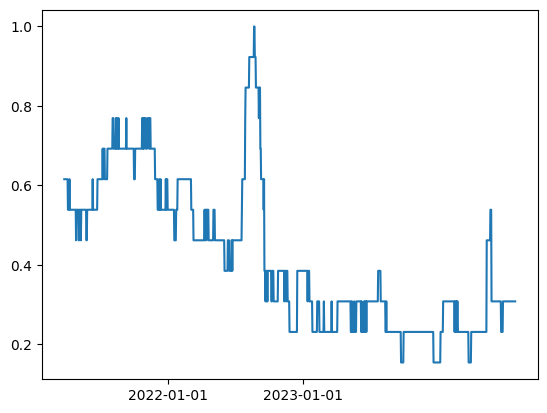

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels, loc='upper left')
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

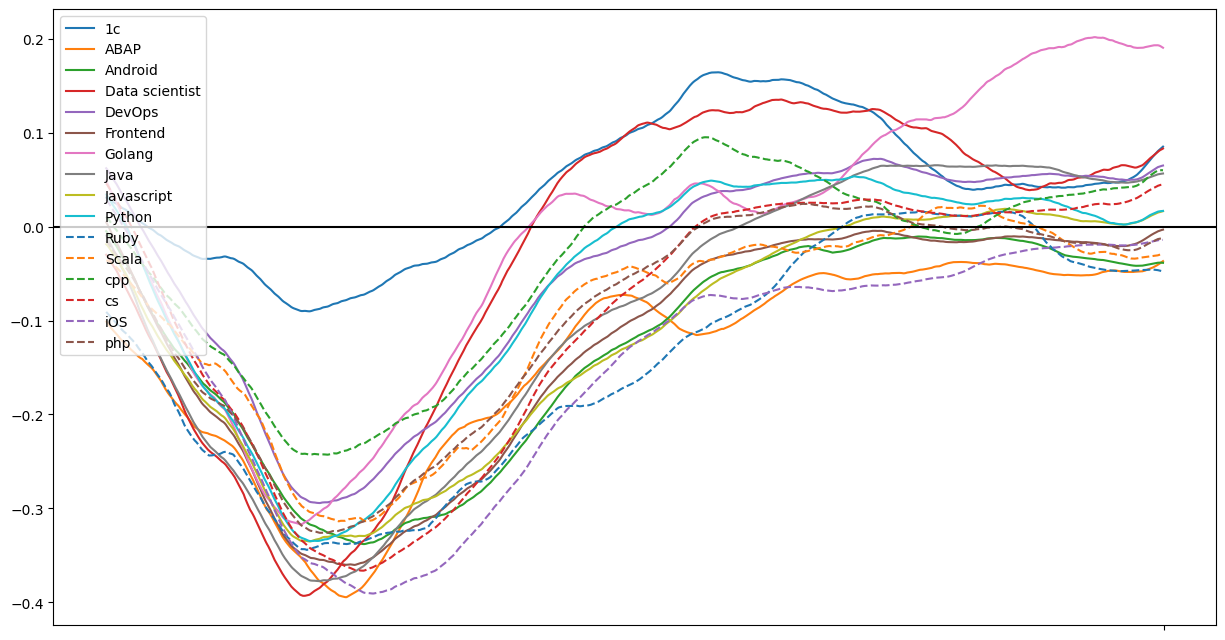

In [8]:
graphs('val', 200)

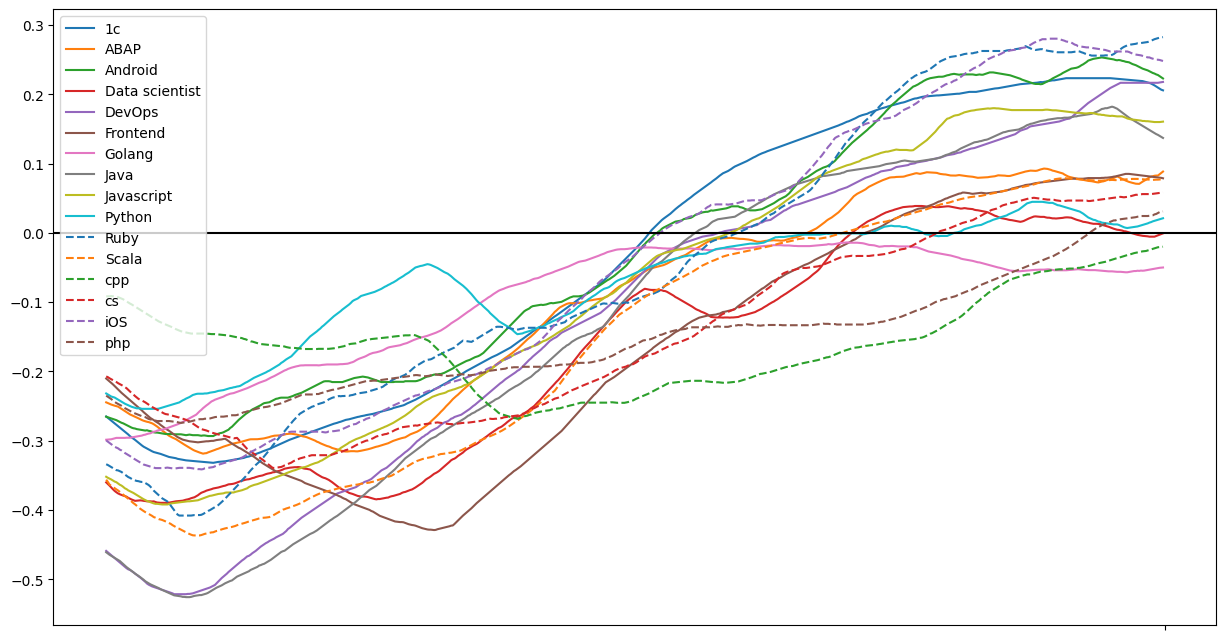

In [9]:
graphs('val_noexp', 300)

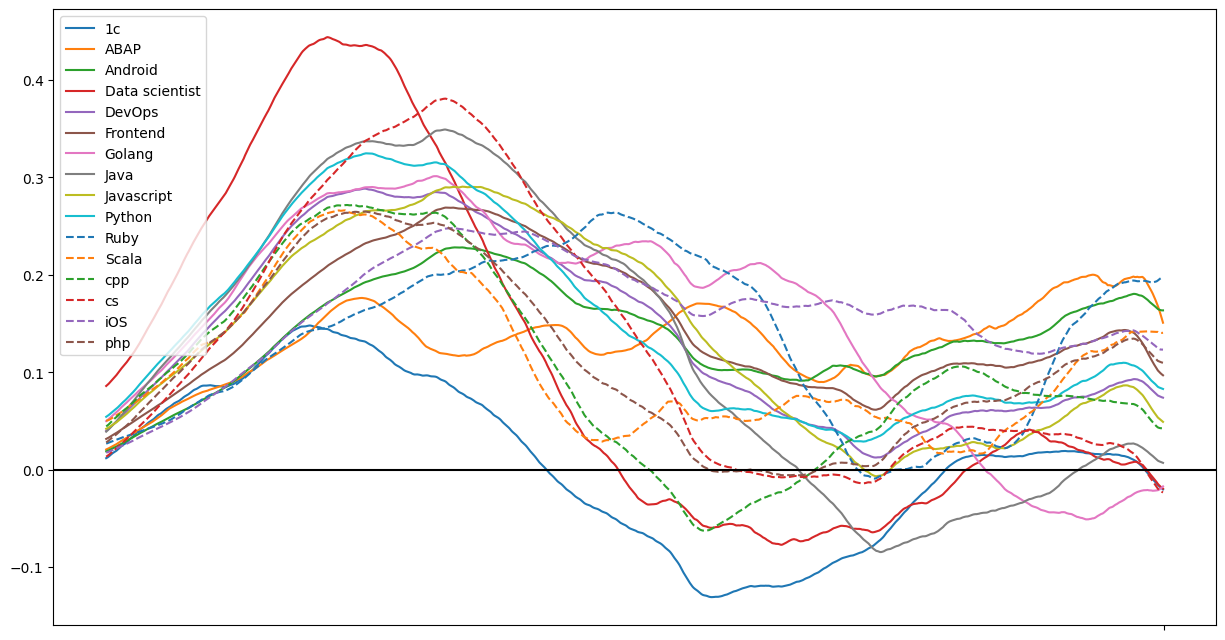

In [10]:
graphs('res_vac', 200)

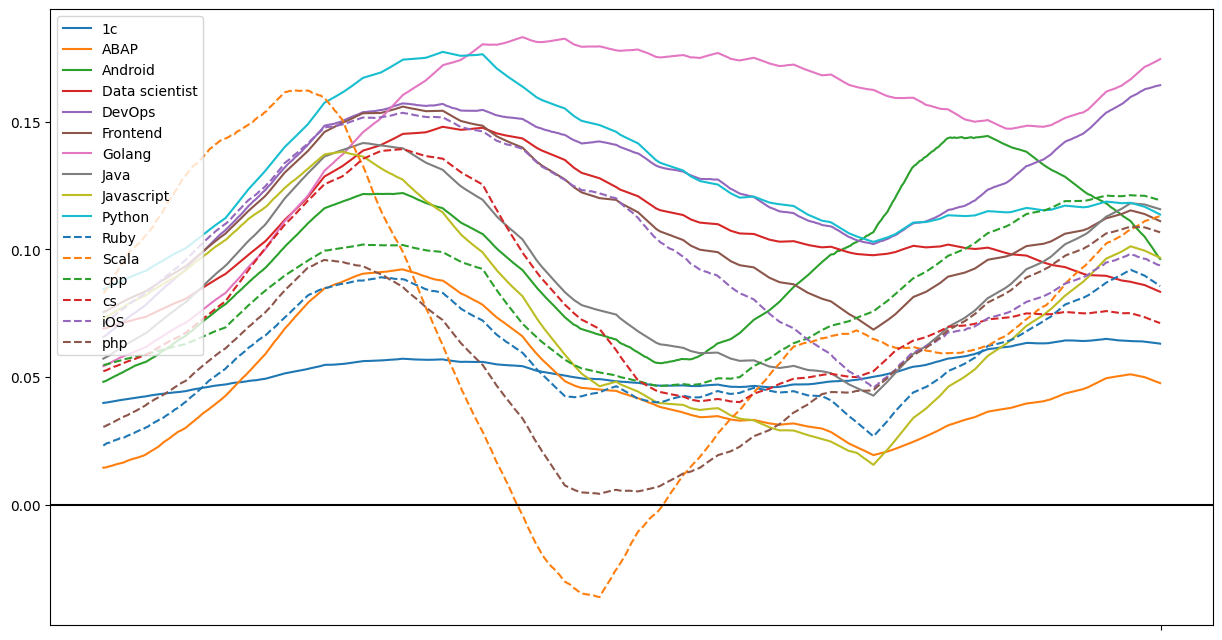

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1222 entries, 2021-03-26 to 2024-07-31
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1222 non-null   float64
 1   (val, ABAP)                  1222 non-null   float64
 2   (val, Android)               1222 non-null   float64
 3   (val, Data scientist)        1222 non-null   float64
 4   (val, DevOps)                1222 non-null   float64
 5   (val, Frontend)              1222 non-null   float64
 6   (val, Golang)                1222 non-null   float64
 7   (val, Java)                  1222 non-null   float64
 8   (val, Javascript)            1222 non-null   float64
 9   (val, Python)                1222 non-null   float64
 10  (val, Ruby)                  1222 non-null   float64
 11  (val, Scala)                 1222 non-null   float64
 12  (val, cpp)                   1222 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

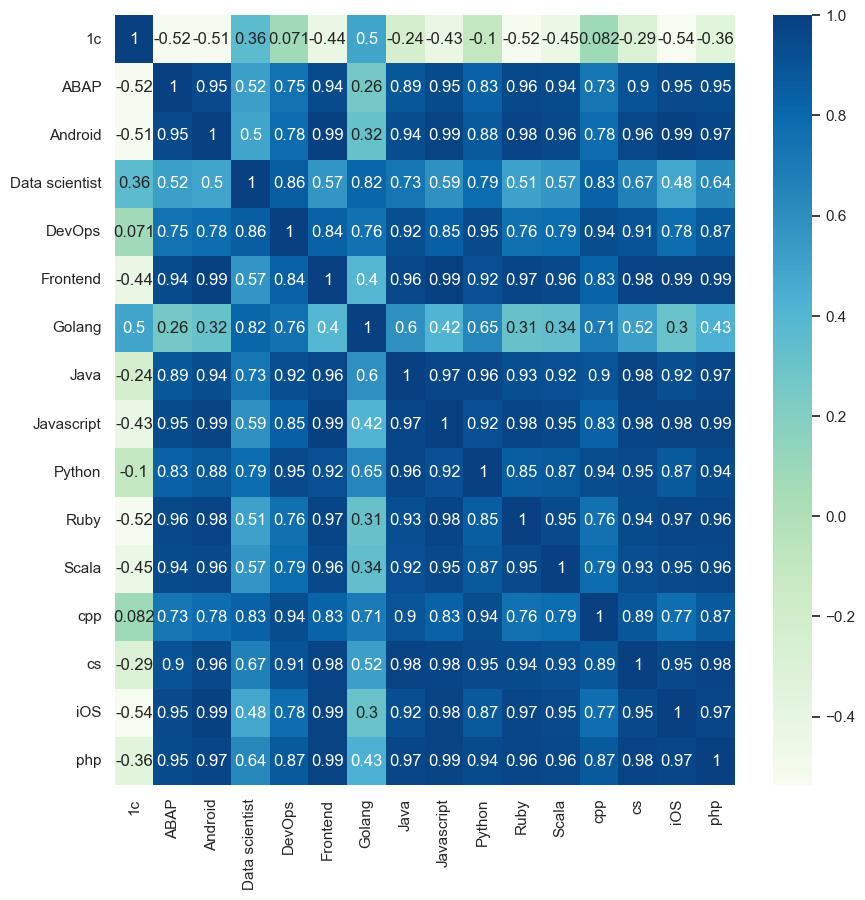

In [14]:
corr('val')

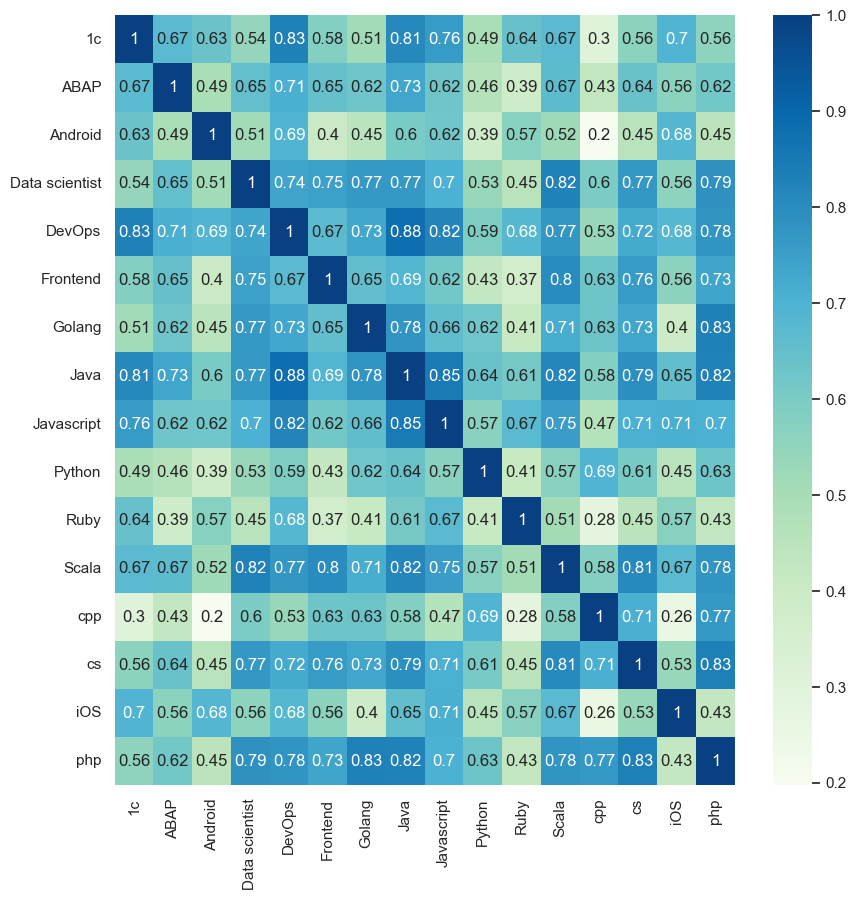

In [15]:
corr('val_noexp')

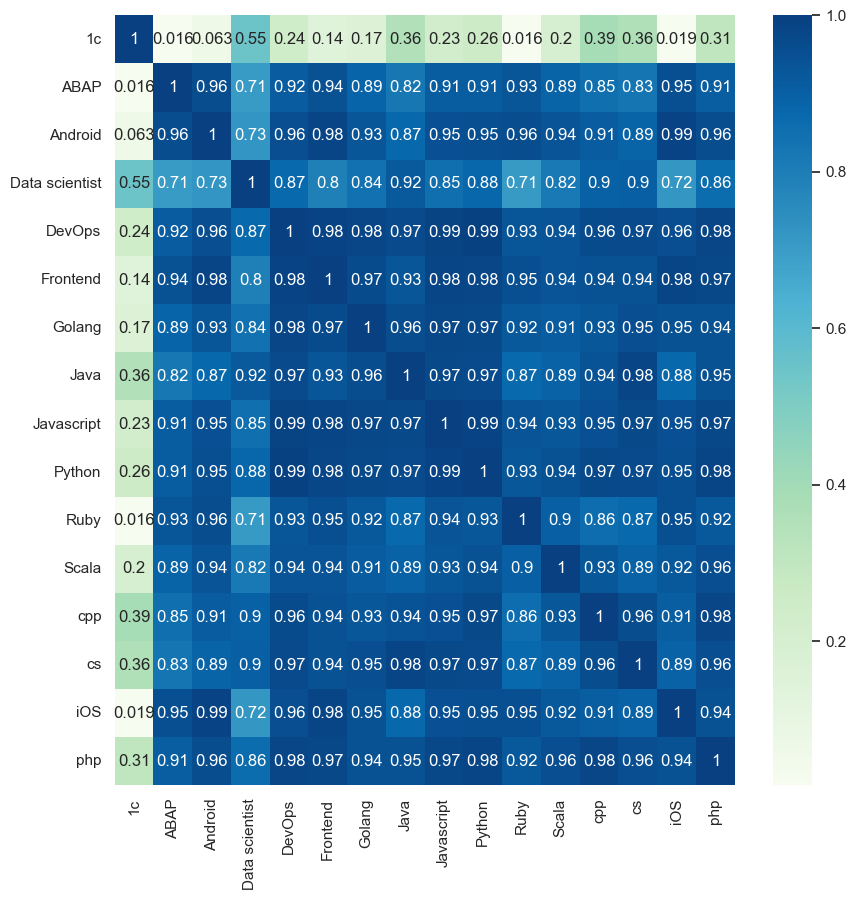

In [16]:
corr('res_vac')

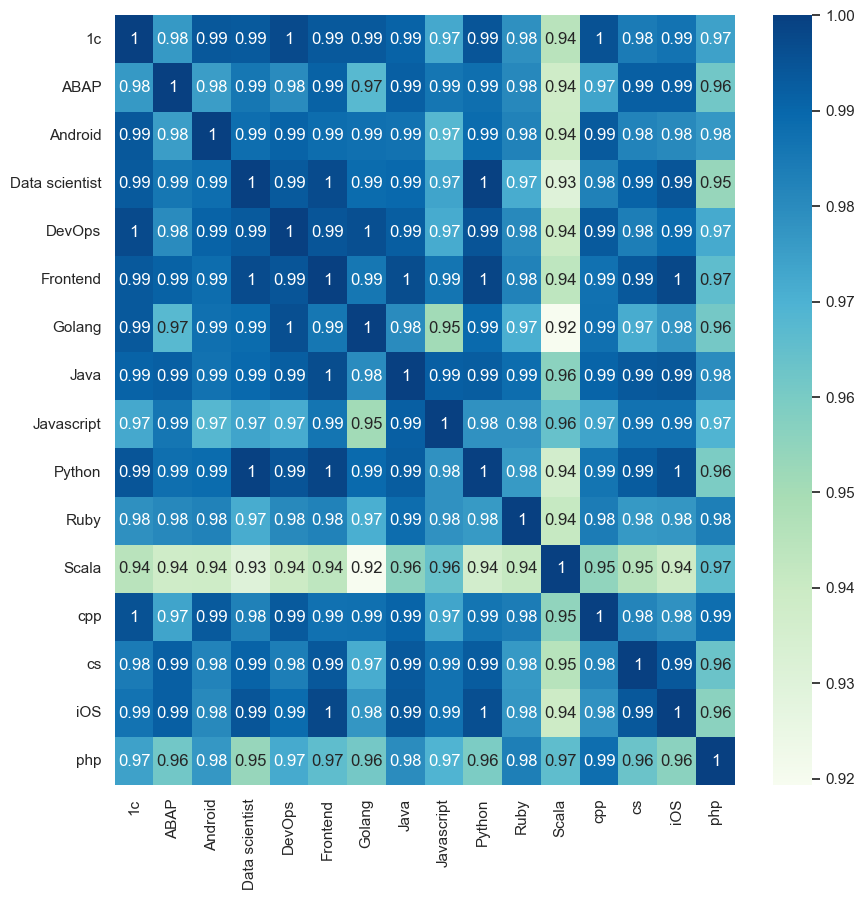

In [17]:
corr('res')

In [18]:
langs.index = pd.to_datetime(langs.index)

def year(x):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    plt.plot(langs[x].groupby(langs.index.strftime('%m-%d')).median().median(axis=1))
    plt.xticks([str(i).zfill(2) + "-01" for i in range(1, 13)])
    plt.grid()

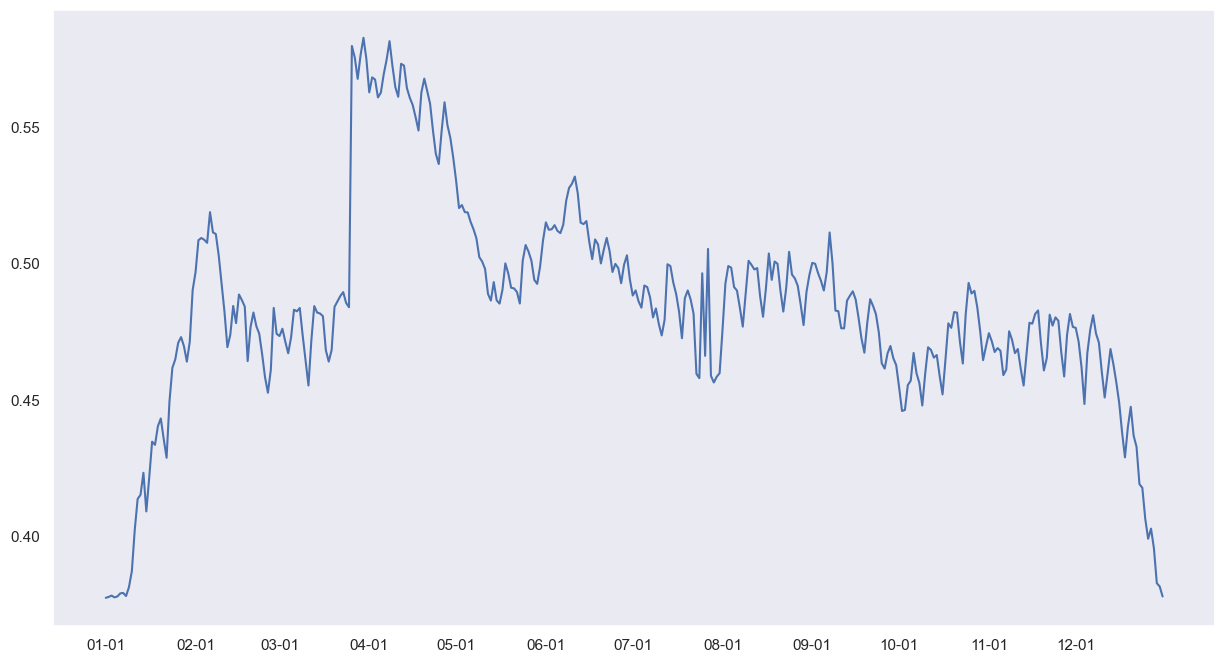

In [19]:
year("val")

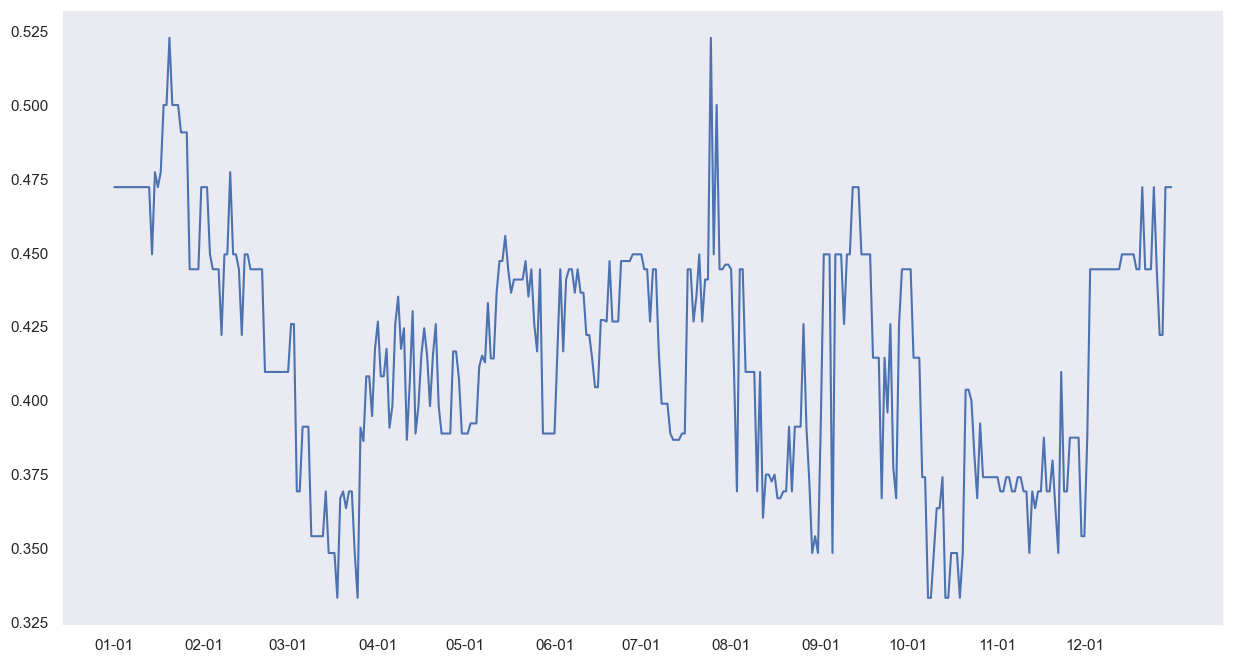

In [20]:
year("val_noexp")

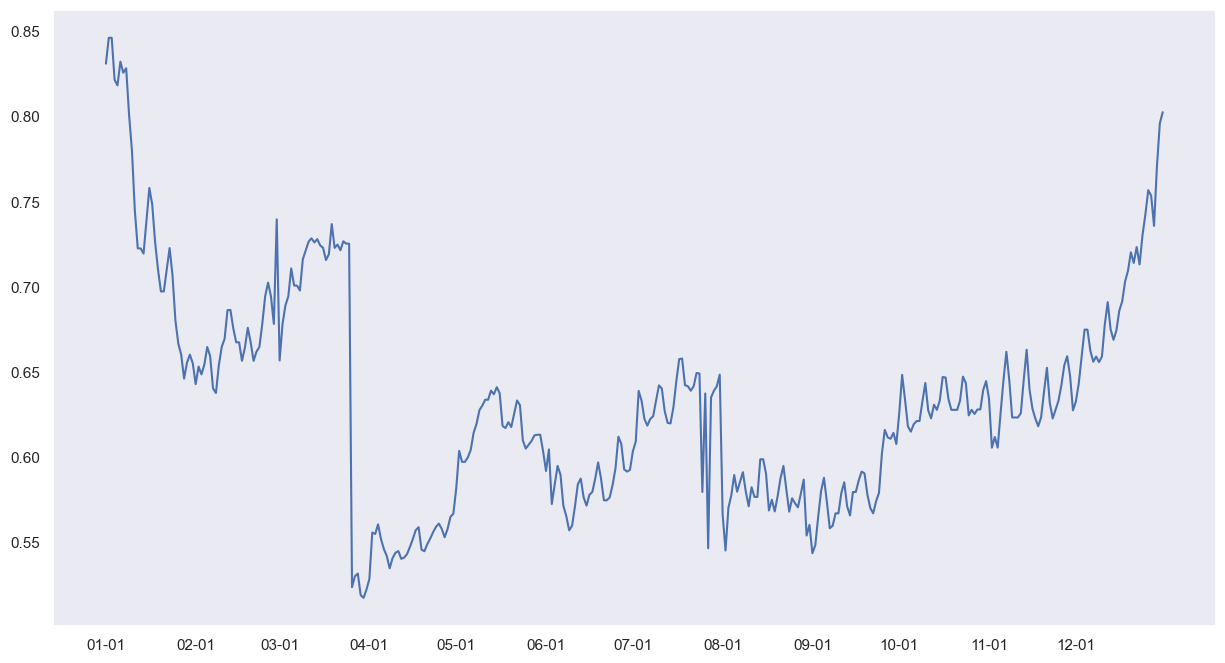

In [21]:
year("res_vac")

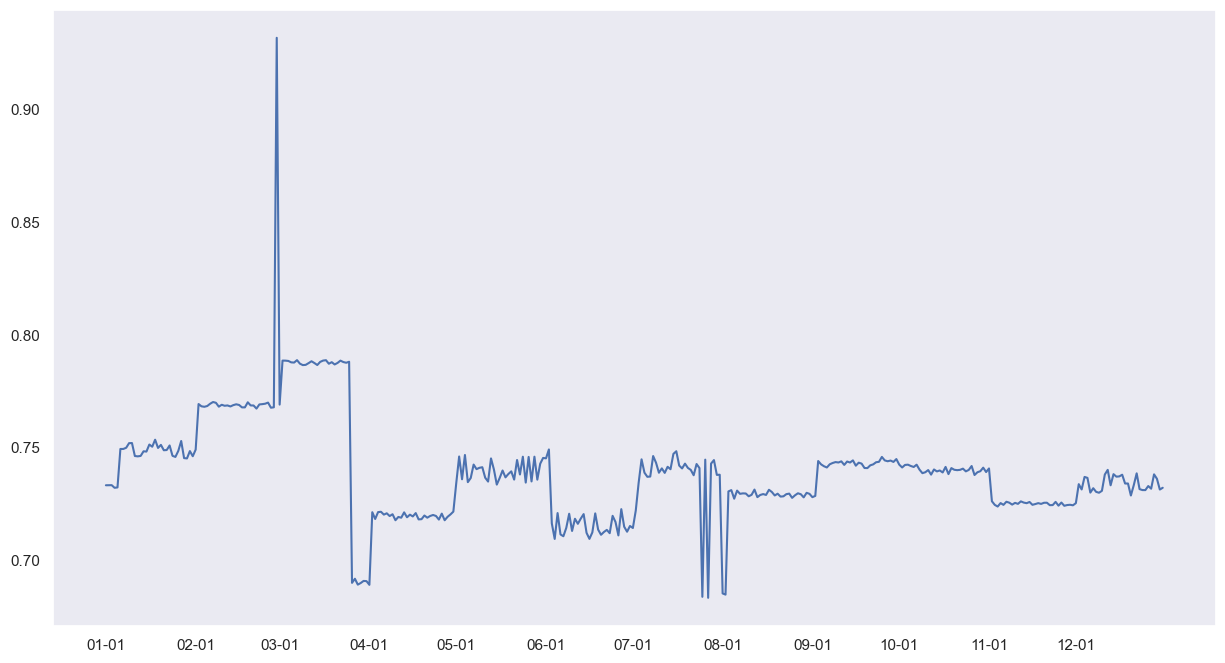

In [22]:
year("res")

In [23]:
def graphs(column, window):
    colmns = langs[column].columns
    langs1 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        
        if col[:2] != 'Py':
            ax.plot(langs1[i])
            labels.append(langs1[i].name)
            col = i
        else:
            ax.plot(langs1[i], linestyle='--')
            labels.append(langs1[i].name)
            col = 'Py'

    ax.legend(labels)
    #plt.xticks('')

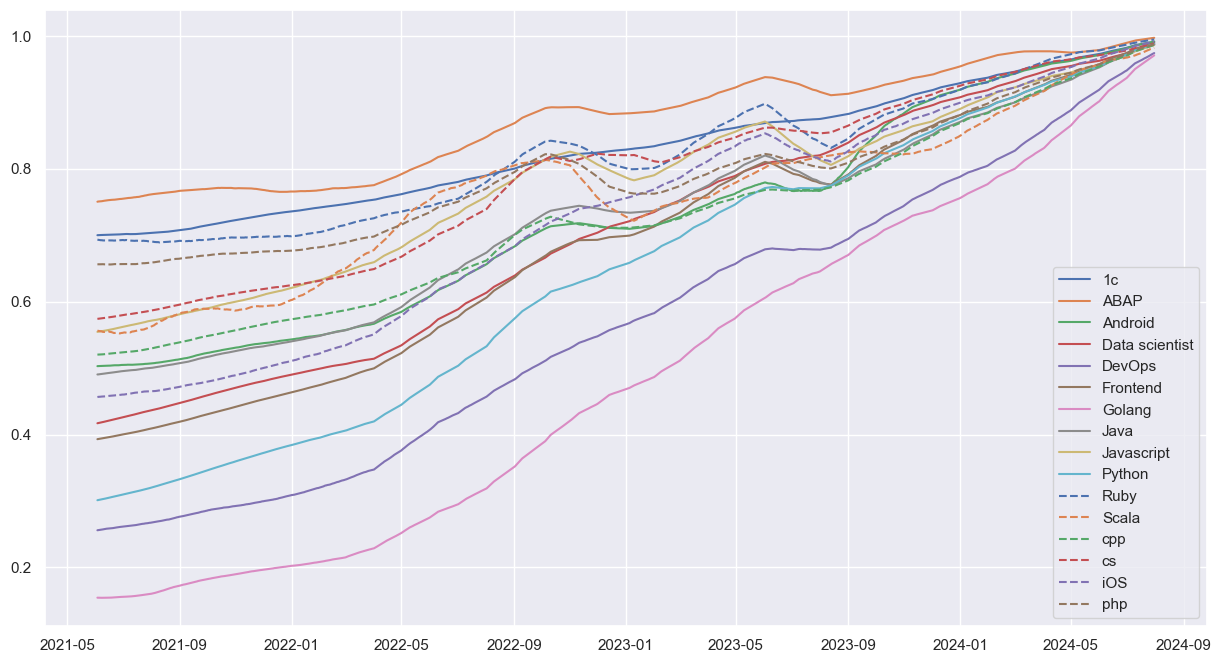

In [24]:
graphs("res", 70)